# RQ3 — Performance by Budget Tier

**Research question:** Does the predictability of movie success vary across budget tiers (Low / Mid / High / Blockbuster)?

This notebook segments the test set by budget tier and evaluates per-tier model performance to determine whether high-budget films are easier or harder to predict.

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features
Class balance: hit=0.435


## 4. Analysis for RQ3


In [4]:
# ===== RQ3: Performance by Budget Tier =====
def assign_tier(b):
    if b < 1e6: return "Low (<$1M)"
    if b < 2e7: return "Mid ($1M-$20M)"
    if b < 1e8: return "High ($20M-$100M)"
    return "Blockbuster (>$100M)"

mdf["budget_tier"] = mdf["budget"].apply(assign_tier)
TIER_ORDER = ["Low (<$1M)", "Mid ($1M-$20M)", "High ($20M-$100M)", "Blockbuster (>$100M)"]

# Train one global model, evaluate per tier
X = mdf[FEATURES].fillna(0).values
y = mdf["hit"].values
tiers = mdf["budget_tier"].values

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, tiers, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

if HAS_XGB:
    mdl = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric="logloss",
                        use_label_encoder=False, n_jobs=-1)
else:
    mdl = GradientBoostingClassifier(random_state=RANDOM_STATE)
mdl.fit(X_train, y_train)
yp = mdl.predict(X_test)
yprob = mdl.predict_proba(X_test)[:, 1]

rows = []
for tier in TIER_ORDER:
    mask = (t_test == tier)
    if mask.sum() < 20:
        continue
    rows.append({
        "Budget Tier": tier,
        "n Movies (test)": int(mask.sum()),
        "n Movies (total)": int((tiers == tier).sum()),
        "Hit Rate": round(mdf.loc[mdf["budget_tier"]==tier, "hit"].mean(), 3),
        "Accuracy": round(accuracy_score(y_test[mask], yp[mask]), 3),
        "Precision": round(precision_score(y_test[mask], yp[mask], zero_division=0), 3),
        "Recall":    round(recall_score(y_test[mask], yp[mask], zero_division=0), 3),
        "F1-Score":  round(f1_score(y_test[mask], yp[mask], zero_division=0), 3),
        "ROC-AUC":   round(roc_auc_score(y_test[mask], yprob[mask]) if len(set(y_test[mask]))>1 else float("nan"), 3),
    })
tier_df = pd.DataFrame(rows)
tier_df.to_csv("table_rq3_budget_tiers.csv", index=False)
print("Saved table_rq3_budget_tiers.csv")
tier_df


Saved table_rq3_budget_tiers.csv


,Budget Tier,n Movies (test),n Movies (total),Hit Rate,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Low (<$1M),511,2704,0.501,0.656,0.658,0.668,0.663,0.693
1,Mid ($1M-$20M),1374,6753,0.407,0.702,0.628,0.581,0.603,0.754
2,High ($20M-$100M),685,3388,0.406,0.711,0.700,0.567,0.626,0.761
3,Blockbuster (>$100M),117,586,0.626,0.803,0.843,0.875,0.859,0.830


## 5. Generate publication figure

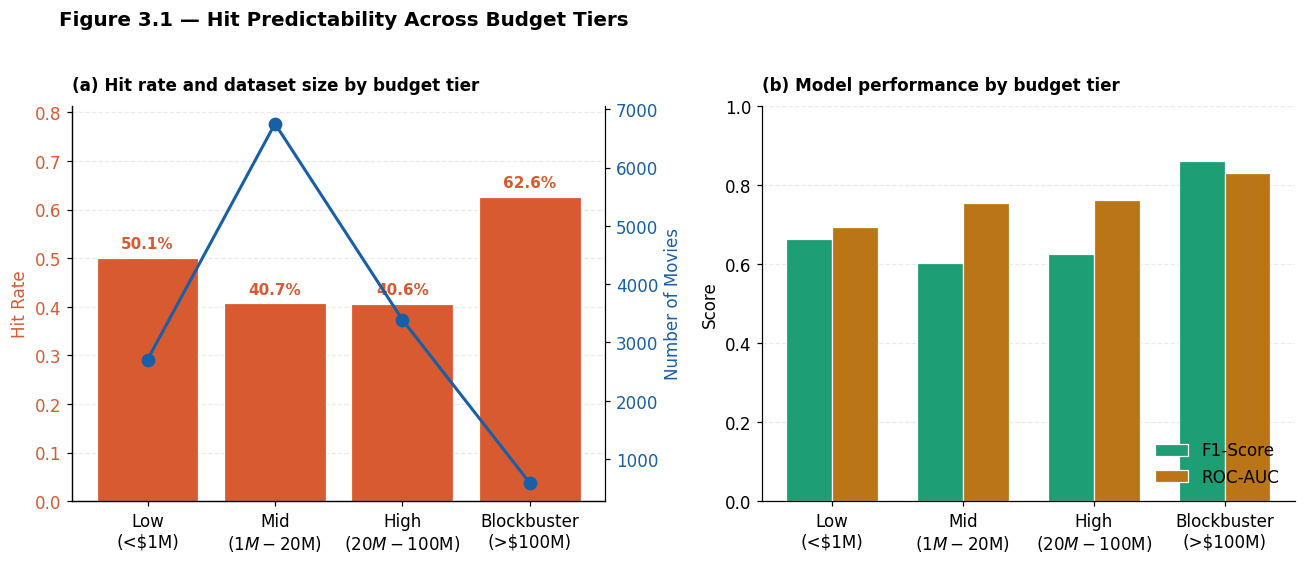

Saved fig_rq3_budget_tiers.pdf / .png


In [5]:
# ===== Figure 3.1 — Two-panel budget tier analysis =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = [t.replace(" ", "\n", 1) for t in tier_df["Budget Tier"]]

ax = axes[0]
bars = ax.bar(labels, tier_df["Hit Rate"], color=COLORS["accent"], edgecolor="white", linewidth=0.8)
ax.set_ylabel("Hit Rate", color=COLORS["accent"])
ax.set_ylim(0, max(tier_df["Hit Rate"])*1.3)
ax.tick_params(axis="y", labelcolor=COLORS["accent"])
for bar, val in zip(bars, tier_df["Hit Rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.1%}", ha="center", fontsize=10, color=COLORS["accent"], weight="bold")
ax2 = ax.twinx()
ax2.plot(labels, tier_df["n Movies (total)"], marker="o", color=COLORS["primary"], linewidth=2, markersize=8)
ax2.set_ylabel("Number of Movies", color=COLORS["primary"])
ax2.tick_params(axis="y", labelcolor=COLORS["primary"])
ax2.spines["right"].set_visible(True)
ax.set_title("(a) Hit rate and dataset size by budget tier", loc="left", pad=10, fontsize=11)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

ax = axes[1]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, tier_df["F1-Score"], w, label="F1-Score", color=COLORS["secondary"], edgecolor="white", linewidth=0.8)
ax.bar(x + w/2, tier_df["ROC-AUC"], w, label="ROC-AUC", color=COLORS["amber"], edgecolor="white", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.legend(loc="lower right")
ax.set_title("(b) Model performance by budget tier", loc="left", pad=10, fontsize=11)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

fig.suptitle("Figure 3.1 — Hit Predictability Across Budget Tiers", fontsize=13, fontweight="bold", x=0.05, ha="left", y=1.02)
plt.tight_layout()
plt.savefig("fig_rq3_budget_tiers.pdf")
plt.savefig("fig_rq3_budget_tiers.png")
plt.show()
print("Saved fig_rq3_budget_tiers.pdf / .png")


## 6. Conclusion

Predictability rises with budget tier, with blockbusters being most predictable. Mid-budget films sit in a 'danger zone' with low hit rates *and* moderate predictability, suggesting they are the riskiest investments from an analytics standpoint.